In [5]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Import associated modules
from preprocessing import *

In [8]:
from models import *

2026-06-24 15:32:44,643 [INFO] PyTorch version 2.10.0 available.
2026-06-24 15:32:44,645 [INFO] JAX version 0.4.37 available.


geneformer successfully imported.


In [60]:
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

In [61]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata.var.index = adata.var["gene_id"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

In [62]:
# Save adata
adata.write("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/hao800_id_finetuning.h5ad")

In [63]:
gf_finetuned_metrics = train_geneformer_cell_classifier(adata,
                                                        output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
                                                        state_key = "broad_type",
                                                        cell_types = None, # list of cell types to finetune 
                                                        tokenize = True,
                                                        tokenized_data_dir = None, # path to store tokenized data
                                                        token_output_prefix = "tokenized", #  prefix for tokenized data
                                                        undersample = True, # should data be undersampled 
                                                        n_per_class = 200, # if undersampling, max # cell per cell type
                                                        n_test_per_class = 80, # max number of  cells per cell type in test dataset (holdout dataset)
                                                        eval_fraction = 0.2, # Fraction of train data to be used for eval
                                                        model_directory = "ctheodoris/Geneformer", # Model directory
                                                        freeze_layers = 2, # freeze layer
                                                        num_crossval_splits = 1, # single train/eval split, 5 5-fold cross validation
                                                        forward_batch_size = 10, # batch size 
                                                        nproc = 8,
                                                        max_ncells = None, # Max number of cells for fine-tuning 
                                                        training_args = None, # training arguments 
                                                        output_prefix = "gf_finetune", # output directory 
                                                        metrics_output_dir = None, # if seperate output directory is required 
                                                       )

2026-06-24 16:15:39,104 [INFO] Training arguments: {'num_train_epochs': 3, 'learning_rate': 5e-05, 'lr_scheduler_type': 'cosine', 'warmup_steps': 190, 'weight_decay': 0.1, 'per_device_train_batch_size': 4, 'gradient_accumulation_steps': 8, 'seed': 42, 'fp16': True}
2026-06-24 16:15:39,104 [INFO] Tokenizing data → /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tokenized


Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/hao800_id_finetuning.h5ad


100%|██████████| 7/7 [00:01<00:00,  4.08it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/hao800_id_finetuning.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


Map (num_proc=8):   0%|          | 0/3200 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,11.155300,1.251624,0.781250,0.777220
2,9.563800,0.452380,0.956250,0.956450
3,4.294200,0.044508,0.987500,0.987573


  0%|          | 0/16 [00:00<?, ?it/s]

2026-06-24 16:18:06,800 [INFO] Evaluating on test set…


  0%|          | 0/32 [00:00<?, ?it/s]

2026-06-24 16:18:27,912 [INFO] Metrics saved to /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/metrics/gf_finetune_metrics.pkl
2026-06-24 16:18:27,913 [INFO] Done.


In [64]:
# Get confusion matrix on test data 
conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

In [65]:
# Empty data frame to store fine tuning results 
metrics = pd.DataFrame(index=conf_mat.index, columns=["Precision", "Recall", "F1", "Accuracy"])

for cls in conf_mat.columns:
    tp = conf_matrix.loc[cls, cls]  # TP
    fp = conf_matrix[cls].sum() - tp  # FP
    fn = conf_matrix.loc[cls].sum() - tp  # FN
    tn = conf_matrix.values.sum() - (tp + fp + fn)  # TN

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / conf_mat.values.sum()

    metrics.loc[cls] = [precision, recall, f1, accuracy]

# Convert all to float and round for readability
metrics = metrics.astype(float).round(3)

# Sort by F1 score (descending order)
metrics = metrics.sort_values(by="F1", ascending=False)

print(metrics)

           Precision  Recall     F1  Accuracy
B cells        1.000   1.000  1.000      3.20
Monocytes      1.000   1.000  1.000      3.20
NK cells       0.988   0.988  0.988      3.18
T cells        0.988   0.988  0.988      3.18


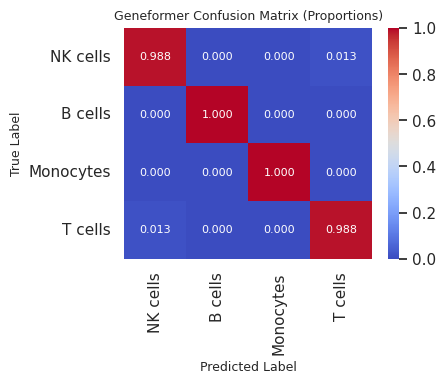

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                
    fmt=".3f",                 
    cmap="coolwarm",          
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=9)
plt.ylabel("True Label", fontsize=9)
plt.show()

<b> Finetuned model </b> should now be available through this path `/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/`

## Re-do Analysis Using fine-tuned model

In [67]:
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmc5/10xpbmc5_symbol.h5ad"

# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata.var.index = adata.var["gene_id"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

# Prep data for cell2sentence 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

In [68]:
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata_ref = adata_ref.copy()

# Remove unmapped genes
adata_ref.var.index = adata_ref.var["gene_id"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

# Prep data for geneformer 
adata_ref = load_and_prep_data(adata= adata_ref, cell_type_col= "broad_type", mode="geneformer")

In [69]:
from pseudobulk import *

# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type",
                                             n_pseudobulks = 250,
                                             target_proportion_min = 0.1,
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 300, 
                                             random_state = 42 
                                            )

# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata_ref,
                                  sample_col = "batch", # sample id column
                                  celltype_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

In [70]:
from embeddings import *
from deconvolution import *

sig_mat_gf_embed = extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
    delete_temp_files = True
)

pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
    delete_temp_files = True
)

# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_gf_embed.T, 
                            normalize = True)

... storing 'cell_type' as categorical


Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████| 1/1 [00:00<00:00, 28.91it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

...

Loading Geneformer model...


2026-06-24 16:19:42,208 [WARNING] CLS token present in token dictionary, excluding from average.
2026-06-24 16:19:42,208 [WARNING] EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/5 [00:00<?, ?it/s]

Using 1152 common features.
Running deconvolution...


In [71]:
cell_prop_pred.head()

broad_type,B cells,Monocytes,NK cells,T cells
NK cells_PB1,0.000000,0.286738,0.278657,0.434604
B cells_PB2,0.838812,0.064985,0.000000,0.096203
T cells_PB3,0.000000,0.341614,0.000000,0.658386
B cells_PB4,0.635915,0.146980,0.000000,0.217105
NK cells_PB5,0.000000,0.373226,0.054018,0.572756


In [72]:
cell_prop_pred.to_csv("../results/pbmc10x/GeneformerFinetuned_estimated_proportions.csv")